# Description of this script

This Python script performs statistical analysis on quantum data (qubits and qutrits) and evaluates their anomaly detection performance. The main tasks include:

1. **Data loading**  
   - Loads `.npz` files containing qubit and qutrit measurement (mostly over 100 executions).  
   - Example datasets: `qubitsReal`, `qutritsReal`, `qutritsTau12E`, `qutritsd0dz`, etc. These files store all the results of the experiment after 100 runs.

2. **Statistical analysis**  
   - Computes **mean** and **median** fidelities for different processes/events:  
     - `HToBB`, `WToQQ`, `TTBar`, `back`  
   - Calculates **Jensen-Shannon Divergence (JSD)** between pairs of distributions to quantify differences.

3. **Anomaly detection metrics**  
   - Converts fidelities into anomaly scores: `anomaly_score = 1 - fidelity`.
   - Calculates **Area Under the ROC Curve (AUC)** for each event type against background.

4. **Aggregated metrics**  
   - Computes average AUC and JSD values over multiple trials (usually 100 iterations).  
   - Stores results for comparison across different quantum states and configurations.

5. **Visualization & summary**  
   - Prints mean and standard deviation of AUC values for each event type.  
   - Optionally, could generate ROC curves for visual evaluation (some imports suggest plotting is planned).

**Summary:**  
The script systematically analyzes qubit and qutrit fidelity data, quantifies distribution differences, and evaluates anomaly detection performance using ROC-AUC and Jensen-Shannon Divergence metrics.


---

---

⚠️ **Warning:**  This script was created for testing and quick calculations and not for the purpose of creating clean and efficient code. Optimisation of this script is planned for the future.

---
---

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance

In [2]:
import numpy as np

# 1. Cargas el contenedor
qubitsR_lt2 = np.load('./npz lt2/np_qubitsReal_lt2.npz', allow_pickle=True)
qutritsR_lt2 = np.load('./npz lt2/np_qutritsReal_lt2.npz', allow_pickle=True)

qubitsS_lt2 = np.load('./npz lt2/QubitsS_l2.npz', allow_pickle=True)
qutritsd0dz_lt2 = np.load('./npz lt2/np_qutrits_d0dz_lt2.npz', allow_pickle=True)
qutrits_tau12E_lt2 = np.load('./npz lt2/np_qutrits_tau12E_lt2.npz', allow_pickle=True)
qutrits_tau23E_lt2 = np.load('./npz lt2/np_qutrits_tau23E_lt2.npz', allow_pickle=True)
qutrits_tau34E_lt2 = np.load('./npz lt2/np_qutrits_tau34E_lt2.npz', allow_pickle=True)




### **Auditoria de tamaños**

### **General functions**

In [4]:
def compute_wasserstein_runs2(signal_runs, background_runs):
    Ws = []

    for s in signal_runs:
        for b in background_runs:
            w = wasserstein_distance(s, b)
            Ws.append(w)

    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_wasserstein_runs(signal_runs, background_runs):
    Ws = [wasserstein_distance(s, b) for s, b in zip(signal_runs, background_runs)]
    
    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_tpr_vs_fpr(
    fpr_list,
    tpr_list,
    signal_label=r"$\text{Signal}$", # Nuevo parámetro para LaTeX
    dataset_label=r"$\text{Dataset}$", # Nuevo parámetro para LaTeX
    target_fprs=None,
    make_plot=False
):
    """
    Calcula TPR medio y std a varios FPR a partir de múltiples curvas ROC.
    Permite personalizar la leyenda con etiquetas LaTeX.
    """
    
    # Configuración opcional para que Matplotlib renderice LaTeX correctamente
    # plt.rcParams.update({"text.usetex": False, "font.family": "serif"})

    if target_fprs is None:
        # Valores típicos de FPR en escala logarítmica para HEP
        target_fprs = np.logspace(-4, 0, 50)

    results = {}

    for target in target_fprs:
        tpr_vals = [
            np.interp(target, fpr, tpr)
            for fpr, tpr in zip(fpr_list, tpr_list)
        ]

        results[target] = (
            np.mean(tpr_vals),
            np.std(tpr_vals)
        )

    # =========================
    # PRINT informativo
    # =========================
    print(f"\n=== TPR vs FPR para {signal_label} ===")
    # Solo imprimimos algunos puntos clave para no saturar la consola
    puntos_clave = [0.1, 0.01, 0.001]
    for target in puntos_clave:
        if target in results:
            m, s = results[target]
            print(f"FPR = {target:.7f} -> TPR = {m:.7f} ± {s}")

    # =========================
    # PLOT
    # =========================
    if make_plot:
        fprs = np.array(list(results.keys()))
        means = np.array([v[0] for v in results.values()])
        stds  = np.array([v[1] for v in results.values()])

        plt.figure(figsize=(7, 5))

        # Usamos la etiqueta LaTeX en el label del plot
        plt.plot(fprs, means, label=f"Mean TPR ({signal_label})", color='blue', lw=2)
        plt.fill_between(fprs, means - stds, means + stds, color='blue', alpha=0.2, label=r"$1\sigma$ band")

        plt.xscale("log")
        plt.xlabel("False Positive Rate (Background Acceptance)")
        plt.ylabel("True Positive Rate (Signal Efficiency)")
        plt.title(f"{signal_label} performance in {dataset_label}")
        
        plt.grid(True, which="both", ls="-", color='whitesmoke', alpha=0.5)
        plt.legend(loc="upper left")

        plt.show()

    return results


def get_tpr_stats(fpr_list, tpr_list, target_fprs=None):
    if target_fprs is None:
        target_fprs = np.logspace(-4, 0, 50)

    results = {}
    for target in target_fprs:
        tpr_vals = [np.interp(target, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)]
        results[target] = (np.mean(tpr_vals), np.std(tpr_vals))
    return results

def add_performance_curve(ax, fpr_list, tpr_list, label, color, target_fprs=None):
    """Calcula y añade una curva con su banda 1-sigma al eje 'ax' proporcionado"""
    stats = get_tpr_stats(fpr_list, tpr_list, target_fprs)
    
    fprs = np.array(list(stats.keys()))
    means = np.array([v[0] for v in stats.values()])
    stds  = np.array([v[1] for v in stats.values()])

    # Dibujamos la línea principal
    ax.plot(fprs, means, label=label, color=color, lw=0.8, zorder=3)
    
    # Dibujamos la banda 1-sigma (fondo blanco significa alpha bajo para no ensuciar)
    ax.fill_between(fprs, 
                    np.maximum(0, means - stds), 
                    np.minimum(1, means + stds), 
                    color=color, alpha=0.3, zorder=2, label=f"$1\sigma$ uncertainty")

### **Qubit-based model** trained on real CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qubitsReal`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [3]:
qubitsR1_back_data = qubitsR_lt2['fil_100_back_S'].squeeze()
qubitsR1_HToBB_data = qubitsR_lt2['fil_100_HToBB_S'].squeeze()
qubitsR1_WToQQ_data = qubitsR_lt2['fil_100_WToQQ_S'].squeeze()
qubitsR1_TTBar_data = qubitsR_lt2['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR1_back_data.shape)
print(qubitsR1_HToBB_data.shape)
print(qubitsR1_WToQQ_data.shape)
print(qubitsR1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [6]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qubitsR1_TTBar_data, qubitsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.0877 ± 0.007082686343653443
WToQQ (Boson W) vs Background |     0.0627 ± 0.007024130935045474
TTBar (Top) vs Background |     0.1010 ± 0.006742733588194372
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.0412 ± 0.0007216177022936911
HToBB (Higgs) vs TTBar (Top) |     0.0417 ± 0.0007915470931460709
WToQQ (Boson W) vs TTBar (Top) |     0.0760 ± 0.0014971051047451994
-------------------------------------------------------


In [7]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qubits10 = []
means_WToQQ_qubits10 = []
means_TTBar_qubits10 = []
means_back_qubits10 = []

median_HToBB_qubits10 = []
median_WToQQ_qubits10 = []
median_TTBar_qubits10 = []
median_back_qubits10 = []

auc_HToBB_list_qubits10 = []
auc_TTBar_list_qubits10 = []
auc_WToQQ_list_qubits10 = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0
# =========================
# Datos
# =========================


# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qubitsR1_back_data[i]
    pdf_HToBB = qubitsR1_HToBB_data[i]
    pdf_WToQQ = qubitsR1_WToQQ_data[i]
    pdf_TTBar = qubitsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

     #----------- Valores estadísticos ----------

    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qubitsR1_back_data[i])
    anomaly_scores_HToBB = 1 - np.array(qubitsR1_HToBB_data[i])
    anomaly_scores_TTBar = 1 - np.array(qubitsR1_TTBar_data[i])
    anomaly_scores_WToQQ = 1 - np.array(qubitsR1_WToQQ_data[i])

    
    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qubits10.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qubits10.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qubits10.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)


fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar



# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qubits10)
std_auc_HToBB  = np.std(auc_HToBB_list_qubits10)
mean_auc_TTBar = np.mean(auc_TTBar_list_qubits10)
std_auc_TTBar  = np.std(auc_TTBar_list_qubits10)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qubits10)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qubits10)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:4f} ± {std_auc_TTBar}")

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}") 

=== AUC (mean ± std) ===
HToBB  : 0.735002 ± 0.05257489024587717
WToQQ  : 0.688718 ± 0.04387676955273613
TTBar  : 0.811670 ± 0.05806938189229996
=== JS distance (mean ± std) ===
HToBB  : 0.005865 ± 0.0001728303176362945
WToQQ  : 0.006112 ± 0.00016680713855970276
TTBar  : 0.005334 ± 0.00018565787774240528
----------------------------------------------------------
HToBB  : 0.007004 ± 6.777921810255108e-05
HToBB  : 0.006317 ± 6.324148699223412e-05
WToQQ  : 0.006607 ± 6.465200383035723e-05


In [39]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 991802
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    99.1802%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 986037
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.6037%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 988595
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.8595%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 985192
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.5192%
------------------------------


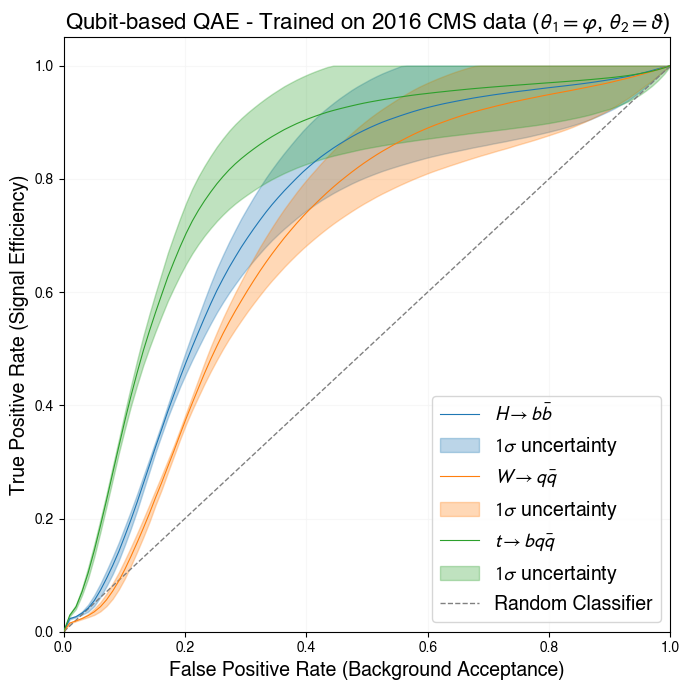

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=14, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=14, fontname="Helvetica")
ax.set_title(r"Qubit-based QAE - Trained on 2016 CMS data ($\theta_1 = \varphi$, $\theta_2 = \vartheta$)", fontsize=16, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})

plt.tight_layout()
plt.show()

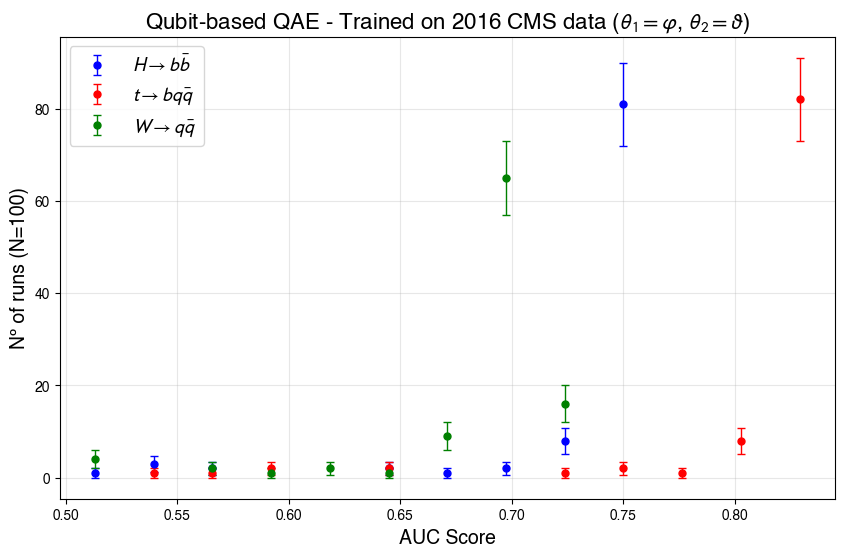

In [60]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qubits10,
    'TTBar': auc_TTBar_list_qubits10,
    'WToQQ': auc_WToQQ_list_qubits10
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qubit-based QAE - Trained on 2016 CMS data ($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=16, fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=14, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=14, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})
plt.grid(alpha=0.3)
plt.show()

In [61]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qubits10) + 
                   np.array(auc_WToQQ_list_qubits10) + 
                   np.array(auc_TTBar_list_qubits10)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qubits10[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qubits10[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qubits10[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 34) ===
AUC HToBB: 0.7624
AUC WToQQ: 0.7142
AUC TTBar: 0.8382


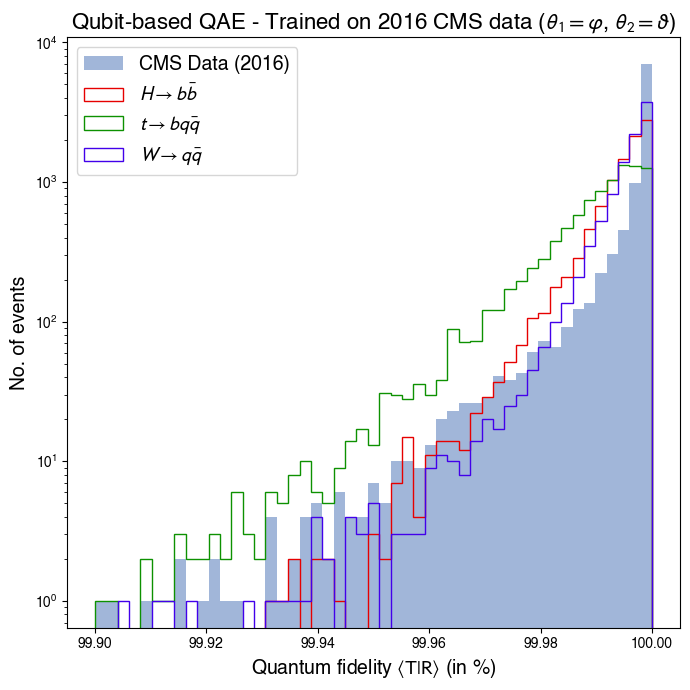

In [64]:

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(99.9, 100, 50)

# Background: blue fill
plt.hist(qubitsR1_back_data[34].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'CMS Data (2016)')

#  H → bb : 
plt.hist(qubitsR1_HToBB_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qubitsR1_TTBar_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qubitsR1_WToQQ_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=14)
plt.ylabel(r'No. of events', fontsize=14)
plt.title(r"Qubit-based QAE - Trained on 2016 CMS data ($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=16, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

### **Qutrit-based** model trained on real CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsReal`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [8]:
qutritsR1_back_data = qutritsR_lt2['fil_100_back_S'].squeeze()
qutritsR1_HToBB_data = qutritsR_lt2['fil_100_HToBB_S'].squeeze()
qutritsR1_WToQQ_data = qutritsR_lt2['fil_100_WToQQ_S'].squeeze()
qutritsR1_TTBar_data = qutritsR_lt2['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsR1_back_data.shape)
print(qutritsR1_HToBB_data.shape)
print(qutritsR1_WToQQ_data.shape)
print(qutritsR1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [9]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsR1_TTBar_data, qutritsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.7556 ± 0.04048746434549502
WToQQ (Boson W) vs Background |     0.2523 ± 0.035446586379237685
TTBar (Top) vs Background |     1.2777 ± 0.04062981117100247
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5286 ± 0.00011873577182913312
HToBB (Higgs) vs TTBar (Top) |     0.5238 ± 0.00022594945569219402
WToQQ (Boson W) vs TTBar (Top) |     1.0508 ± 0.00034871850383908425
-------------------------------------------------------


In [10]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsReal = []
means_WToQQ_qutritsReal = []
means_TTBar_qutritsReal = []
means_back_qutritsReal = []

median_HToBB_qutritsReal = []
median_WToQQ_qutritsReal = []
median_TTBar_qutritsReal = []
median_back_qutritsReal = []

auc_HToBB_list_qutritsReal = []
auc_TTBar_list_qutritsReal = []
auc_WToQQ_list_qutritsReal = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qutritsR1_back_data[i]
    pdf_HToBB = qutritsR1_HToBB_data[i]
    pdf_WToQQ = qutritsR1_WToQQ_data[i]
    pdf_TTBar = qutritsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsR1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsR1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsR1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsR1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qutritsReal.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qutritsReal.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qutritsReal.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar


# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qutritsReal)
std_auc_HToBB  = np.std(auc_HToBB_list_qutritsReal)
mean_auc_TTBar = np.mean(auc_TTBar_list_qutritsReal)
std_auc_TTBar  = np.std(auc_TTBar_list_qutritsReal)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qutritsReal)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qutritsReal)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")


=== AUC (mean ± std) ===
HToBB  : 0.7116 ± 0.0024364884850300817
WToQQ  : 0.6688 ± 0.00251502754895986
TTBar  : 0.7911 ± 0.0021766013159541333
=== JS distance (mean ± std) ===
HToBB  : 0.039510 ± 0.0005539820266996468
WToQQ  : 0.032875 ± 0.0005750065711576399
TTBar  : 0.042230 ± 0.0004969564488875514
----------------------------------------------------------
HToBB  : 0.041498 ± 7.8752442444903e-06
HToBB  : 0.049200 ± 8.96706265325635e-06
WToQQ  : 0.044701 ± 8.676875205535972e-06


In [44]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 981750
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1750%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 972700
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.2700%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 980798
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.0798%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960495
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0495%
------------------------------


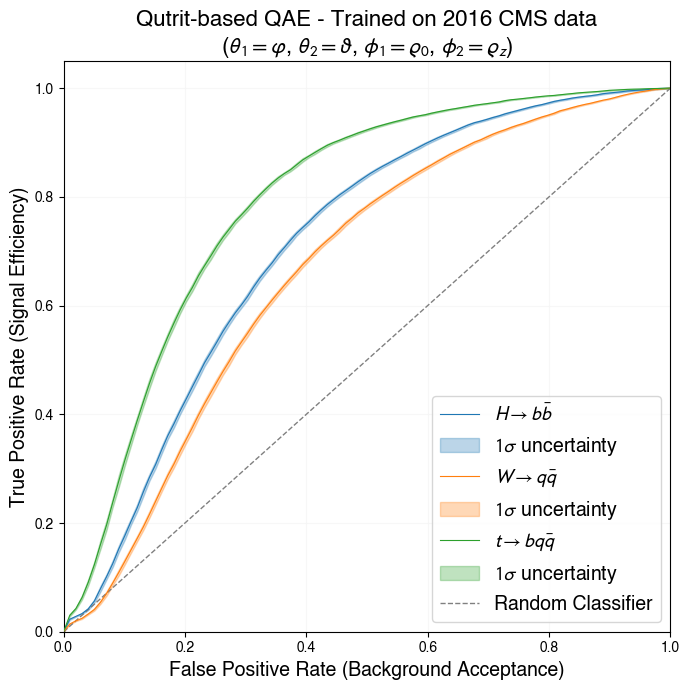

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=14, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=14, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=16, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})

plt.tight_layout()
plt.show()

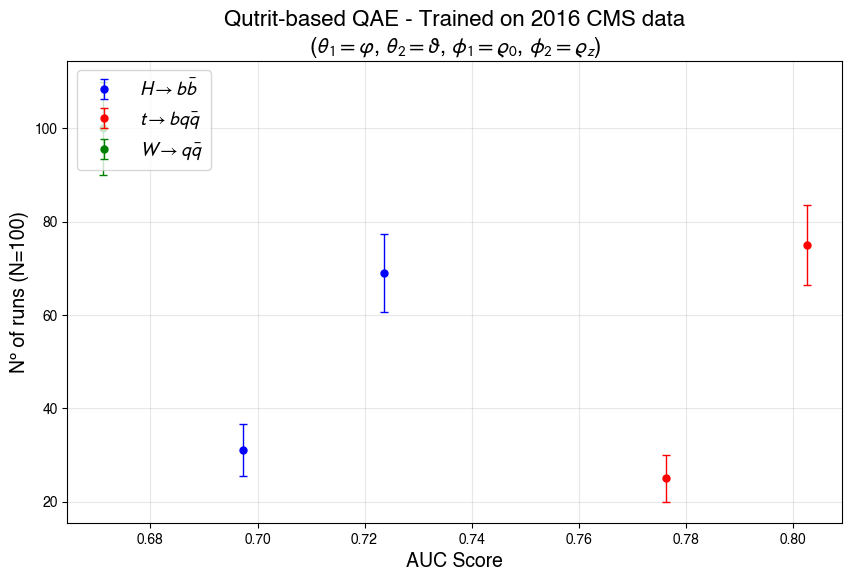

In [71]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsReal,
    'TTBar': auc_TTBar_list_qutritsReal,
    'WToQQ': auc_WToQQ_list_qutritsReal
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=16, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=14, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=14, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})
plt.grid(alpha=0.3)
plt.show()

### **Qubit-based** model trained on simulated CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qubits`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [11]:
qubitsS1_back_data  = qubitsS_lt2['fil_100_back_S'].squeeze()
qubitsS1_HToBB_data = qubitsS_lt2['fil_100_HToBB_S'].squeeze()
qubitsS1_WToQQ_data = qubitsS_lt2['fil_100_WToQQ_S'].squeeze()
qubitsS1_TTBar_data = qubitsS_lt2['fil_100_TTBar_S'].squeeze()

print(qubitsS1_back_data.shape)
print(qubitsS1_HToBB_data.shape)
print(qubitsS1_WToQQ_data.shape)
print(qubitsS1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [12]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qubitsS1_WToQQ_data, qubitsS1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qubitsS1_TTBar_data, qubitsS1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qubitsS1_WToQQ_data, qubitsS1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.1528 ± 0.013516528286367025
WToQQ (Boson W) vs Background |     0.1295 ± 0.01475956790230433
TTBar (Top) vs Background |     0.2075 ± 0.01067695572218427
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.0818 ± 0.00065773943919818
HToBB (Higgs) vs TTBar (Top) |     0.0738 ± 0.0009423144617845444
WToQQ (Boson W) vs TTBar (Top) |     0.1551 ± 0.0015895528516396942
-------------------------------------------------------


In [13]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qubits = []
means_WToQQ_qubits = []
means_TTBar_qubits = []
means_back_qubits = []

median_HToBB_qubits = []
median_WToQQ_qubits = []
median_TTBar_qubits = []
median_back_qubits = []

auc_HToBB_list_qubits = []
auc_TTBar_list_qubits = []
auc_WToQQ_list_qubits = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- Stats ----------


    # ---------- PDFs ----------
    pdf_back  = qubitsS1_back_data[i]
    pdf_HToBB = qubitsS1_HToBB_data[i]
    pdf_WToQQ = qubitsS1_WToQQ_data[i]
    pdf_TTBar = qubitsS1_TTBar_data[i]

    # ---------- JS divergence ----------
    len_h_b = min(len(pdf_HToBB), len(pdf_back))
    len_w_b = min(len(pdf_WToQQ), len(pdf_back))
    len_t_b = min(len(pdf_TTBar), len(pdf_back))

    # 2. Aplicamos el recorte [:min_len] directamente en la función
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:len_h_b], pdf_back[:len_h_b]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:len_w_b], pdf_back[:len_w_b]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:len_t_b], pdf_back[:len_t_b]))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))


    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qubitsS1_back_data[i]
    anomaly_scores_HToBB = 1 - qubitsS1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qubitsS1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qubitsS1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qubits.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qubits.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qubits.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qubits)
std_auc_HToBB  = np.std(auc_HToBB_list_qubits)

mean_auc_TTBar = np.mean(auc_TTBar_list_qubits)
std_auc_TTBar  = np.std(auc_TTBar_list_qubits)

mean_auc_WToQQ = np.mean(auc_WToQQ_list_qubits)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qubits)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")  

=== AUC (mean ± std) ===
HToBB  : 0.7615 ± 0.0027931341161117297
WToQQ  : 0.7192 ± 0.0029568084941169566
TTBar  : 0.8270 ± 0.0023056192274169183
=== JS distance (mean ± std) ===
HToBB  : 0.011191 ± 0.000410327897686806
WToQQ  : 0.012405 ± 0.0003672787037410801
TTBar  : 0.010787 ± 0.00042796955284802235
----------------------------------------------------------
HToBB  : 0.013854 ± 0.00013352108366303163
HToBB  : 0.012393 ± 0.00016342895499491103
WToQQ  : 0.013538 ± 0.00014229739033769857


In [49]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 987829
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.7829%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 982546
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.2546%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 987587
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.7587%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 977957
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.7957%
------------------------------


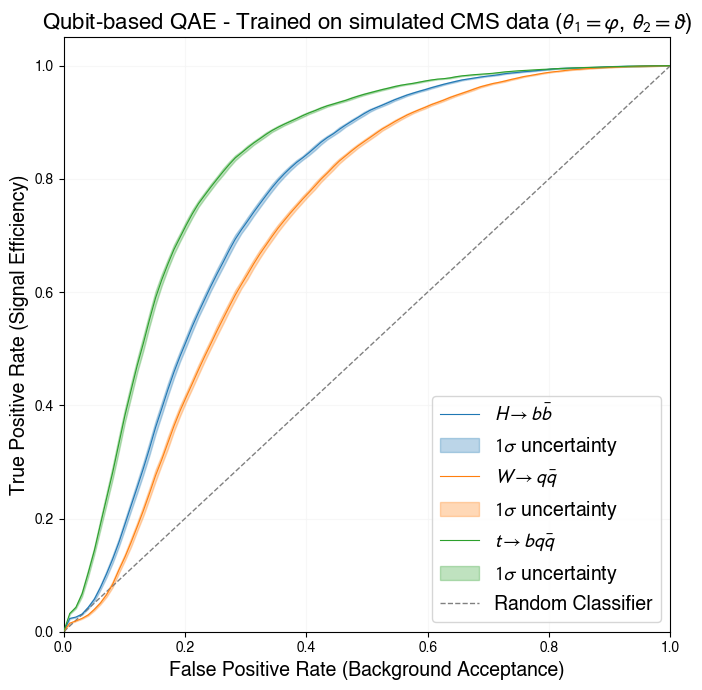

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=14, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=14, fontname="Helvetica")
ax.set_title(r"Qubit-based QAE - Trained on simulated CMS data ($\theta_1 = \varphi$, $\theta_2 = \vartheta$)", fontsize=16, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})

plt.tight_layout()
plt.show()

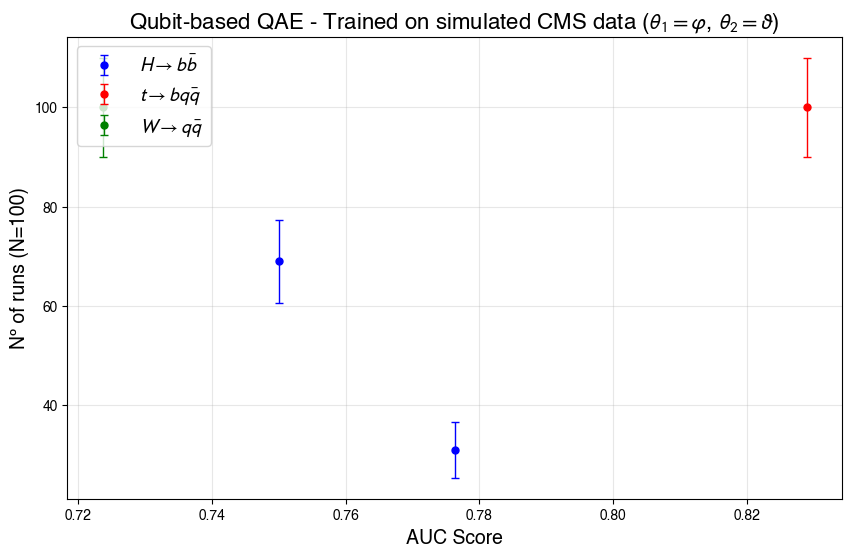

In [76]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qubits,
    'TTBar': auc_TTBar_list_qubits,
    'WToQQ': auc_WToQQ_list_qubits
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qubit-based QAE - Trained on simulated CMS data ($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=16, fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=14, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=14, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})
plt.grid(alpha=0.3)
plt.show()

### **Qutrits-based** model trained on simulated CMS data and using the **longitudinal and trasversal impact parameters** [d0, dz] (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsd0dz`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [14]:
qutritsS1_d0dz_back_data  = qutritsd0dz_lt2['fil_100_back_S'].squeeze()
qutritsS1_d0dz_HToBB_data = qutritsd0dz_lt2['fil_100_HToBB_S'].squeeze()
qutritsS1_d0dz_WToQQ_data = qutritsd0dz_lt2['fil_100_WToQQ_S'].squeeze()
qutritsS1_d0dz_TTBar_data = qutritsd0dz_lt2['fil_100_TTBar_S'].squeeze()

print(qutritsS1_d0dz_back_data.shape)
print(qutritsS1_d0dz_HToBB_data.shape)
print(qutritsS1_d0dz_WToQQ_data.shape)
print(qutritsS1_d0dz_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [15]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsS1_d0dz_WToQQ_data, qutritsS1_d0dz_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_TTBar_data, qutritsS1_d0dz_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_WToQQ_data, qutritsS1_d0dz_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8305 ± 0.04167378195450285
WToQQ (Boson W) vs Background |     0.3068 ± 0.03942822304145975
TTBar (Top) vs Background |     1.3527 ± 0.04162580278139904
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5286 ± 0.0003475283261793984
HToBB (Higgs) vs TTBar (Top) |     0.5237 ± 0.00034018400417398185
WToQQ (Boson W) vs TTBar (Top) |     1.0508 ± 0.0006897629460667808
-------------------------------------------------------


In [16]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsd0dz = []
means_WToQQ_qutritsd0dz = []
means_TTBar_qutritsd0dz = []
means_back_qutritsd0dz = []

median_HToBB_qutritsd0dz = []
median_WToQQ_qutritsd0dz = []
median_TTBar_qutritsd0dz = []
median_back_qutritsd0dz = []

auc_HToBB_list_qutritsd0dz = []
auc_TTBar_list_qutritsd0dz = []
auc_WToQQ_list_qutritsd0dz = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsS1_d0dz_back_data[i]
    pdf_HToBB = qutritsS1_d0dz_HToBB_data[i]
    pdf_WToQQ = qutritsS1_d0dz_WToQQ_data[i]
    pdf_TTBar = qutritsS1_d0dz_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales (también con recorte por seguridad)
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsS1_d0dz_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsS1_d0dz_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsS1_d0dz_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsS1_d0dz_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsd0dz.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsd0dz.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsd0dz.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Promedios finales
# =========================

print("=== Resultados qutritsd0dz ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsd0dz):.4f} ± {np.std(auc_HToBB_list_qutritsd0dz)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsd0dz):.4f} ± {np.std(auc_WToQQ_list_qutritsd0dz)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsd0dz):.4f} ± {np.std(auc_TTBar_list_qutritsd0dz)}")

print("\n=== JS Distance (Promedio) ===")
print(f"JSD HToBB-Back: {np.mean(jsd_HToBB_back):.4f} ± {np.std(jsd_HToBB_back)}")
print(f"JSD WToQQ-Back: {np.mean(jsd_WToQQ_back):.4f} ± {np.std(jsd_WToQQ_back)}")
print(f"JSD TTBar-Back: {np.mean(jsd_TTBar_back):.4f} ± {np.std(jsd_TTBar_back)}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== Resultados qutritsd0dz ===
AUC HToBB: 0.7278 ± 0.003482456112352907
AUC WToQQ: 0.6844 ± 0.003508405309760974
AUC TTBar: 0.8070 ± 0.0031664910796623735

=== JS Distance (Promedio) ===
JSD HToBB-Back: 0.0393 ± 0.0005155673422144049
JSD WToQQ-Back: 0.0326 ± 0.0006281005307934912
JSD TTBar-Back: 0.0420 ± 0.000531422548628699
=== JS distance (mean ± std) ===
HToBB  : 0.039307 ± 0.0005155673422144049
WToQQ  : 0.032647 ± 0.0006281005307934912
TTBar  : 0.042044 ± 0.000531422548628699
----------------------------------------------------------
HToBB  : 0.041498 ± 1.3541800446548627e-05
HToBB  : 0.049200 ± 1.60981617425012e-05
WToQQ  : 0.044701 ± 1.455687503315753e-05


In [18]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 988167
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.8167%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 976400
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.6400%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 985297
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.5297%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 967797
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.7797%
------------------------------


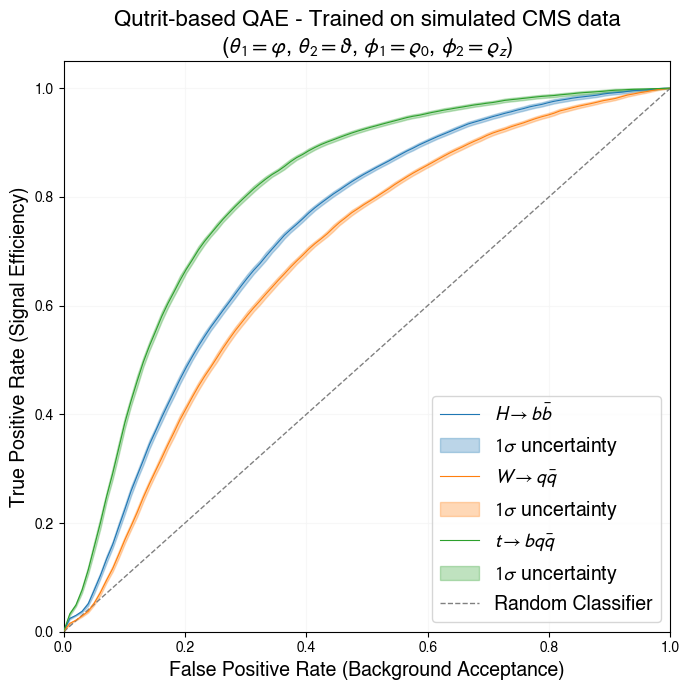

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=14, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=14, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=16, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})

plt.tight_layout()
plt.show()

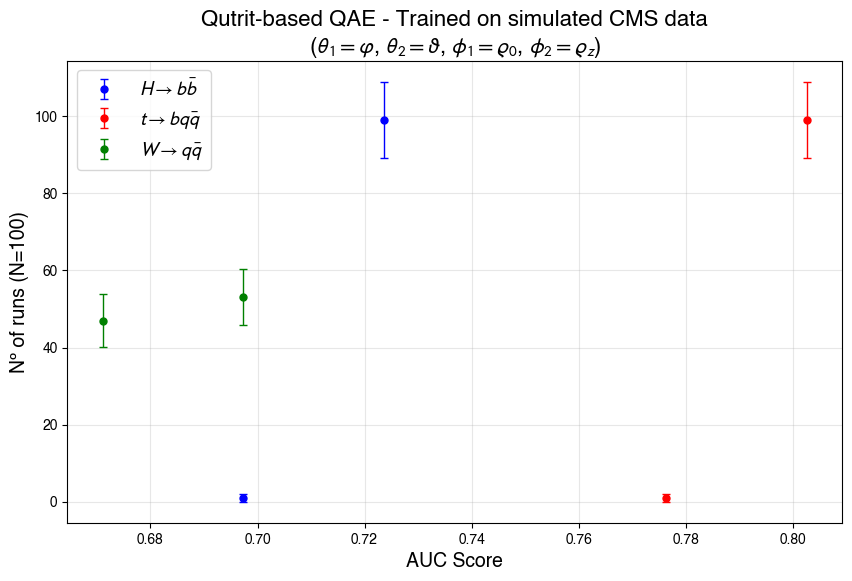

In [81]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans" # Para que el LaTeX se parezca más a Helvetica
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsd0dz,
    'TTBar': auc_TTBar_list_qutritsd0dz,
    'WToQQ': auc_WToQQ_list_qutritsd0dz
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=16, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=14, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=14, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 14})
plt.grid(alpha=0.3)
plt.show()

### **Qutrits-based** model trained on simulated CMS data and using $\tau_{12}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau12E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [17]:
qutrits_tau12E_lt1_back_data  = qutrits_tau12E_lt2['fil_100_back_S'].squeeze()
qutrits_tau12E_lt1_HToBB_data = qutrits_tau12E_lt2['fil_100_HToBB_S'].squeeze()
qutrits_tau12E_lt1_WToQQ_data = qutrits_tau12E_lt2['fil_100_WToQQ_S'].squeeze()
qutrits_tau12E_lt1_TTBar_data = qutrits_tau12E_lt2['fil_100_TTBar_S'].squeeze()

print(qutrits_tau12E_lt1_back_data.shape)
print(qutrits_tau12E_lt1_HToBB_data.shape)
print(qutrits_tau12E_lt1_WToQQ_data.shape)
print(qutrits_tau12E_lt1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [18]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutrits_tau12E_lt1_WToQQ_data, qutrits_tau12E_lt1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_TTBar_data, qutrits_tau12E_lt1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_WToQQ_data, qutrits_tau12E_lt1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8272 ± 0.040642806081073825
WToQQ (Boson W) vs Background |     0.3093 ± 0.03861075539231439
TTBar (Top) vs Background |     1.3512 ± 0.04028953787350398
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5315 ± 0.001334639467787102
HToBB (Higgs) vs TTBar (Top) |     0.5258 ± 0.0020837808953056694
WToQQ (Boson W) vs TTBar (Top) |     1.0556 ± 0.0029086651985623575
-------------------------------------------------------


In [19]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau12E = []
means_WToQQ_qutritsTau12E = []
means_TTBar_qutritsTau12E = []
means_back_qutritsTau12E = []

median_HToBB_qutritsTau12E = []
median_WToQQ_qutritsTau12E = []
median_TTBar_qutritsTau12E = []
median_back_qutritsTau12E = []

auc_HToBB_list_qutritsTau12E = []
auc_TTBar_list_qutritsTau12E = []
auc_WToQQ_list_qutritsTau12E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutrits_tau12E_lt1_back_data[i]
    pdf_HToBB = qutrits_tau12E_lt1_HToBB_data[i]
    pdf_WToQQ = qutrits_tau12E_lt1_WToQQ_data[i]
    pdf_TTBar = qutrits_tau12E_lt1_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:len_h_b], pdf_back[:len_h_b]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:len_w_b], pdf_back[:len_w_b]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:len_t_b], pdf_back[:len_t_b]))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutrits_tau12E_lt1_back_data[i]
    anomaly_scores_HToBB = 1 - qutrits_tau12E_lt1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutrits_tau12E_lt1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutrits_tau12E_lt1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau12E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau12E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau12E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau12E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau12E):.4f} ± {np.std(auc_HToBB_list_qutritsTau12E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau12E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau12E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau12E):.4f} ± {np.std(auc_TTBar_list_qutritsTau12E)}")


print("\n=== JS Distance (Promedio) ===")
print(f"JSD HToBB-Back: {np.mean(jsd_HToBB_back):.4f} ± {np.std(jsd_HToBB_back)}")
print(f"JSD WToQQ-Back: {np.mean(jsd_WToQQ_back):.4f} ± {np.std(jsd_WToQQ_back)}")
print(f"JSD TTBar-Back: {np.mean(jsd_TTBar_back):.4f} ± {np.std(jsd_TTBar_back)}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")


=== Resultados qutritsTau12E ===
AUC HToBB: 0.7561 ± 0.009732980632994305
AUC WToQQ: 0.7145 ± 0.009380353599091553
AUC TTBar: 0.8275 ± 0.008570494976837185

=== JS Distance (Promedio) ===
JSD HToBB-Back: 0.0393 ± 0.0005300162801021146
JSD WToQQ-Back: 0.0326 ± 0.000639507266792623
JSD TTBar-Back: 0.0420 ± 0.0005480668347832991
=== JS distance (mean ± std) ===
HToBB  : 0.039292 ± 0.0005300162801021146
WToQQ  : 0.032613 ± 0.000639507266792623
TTBar  : 0.041980 ± 0.0005480668347832991
----------------------------------------------------------
HToBB  : 0.041487 ± 7.070430239568017e-05
HToBB  : 0.049136 ± 8.283015348906394e-05
WToQQ  : 0.044633 ± 7.545703402711432e-05


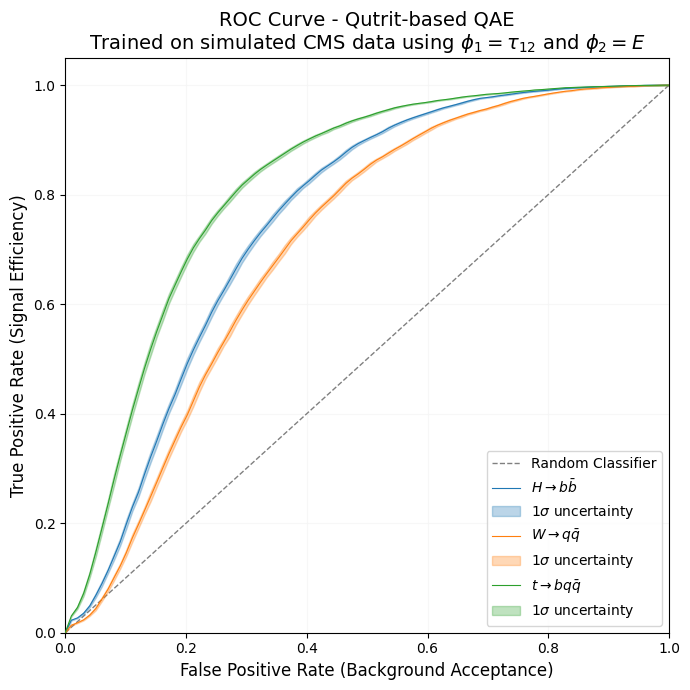

In [23]:
# ==========================================
# CONFIGURACIÓN DEL PLOT LINEAL (ROC ESTÁNDAR)
# ==========================================

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white') # Cuadrada suele verse mejor en lineal
ax.set_facecolor('white')

# Añadimos la diagonal de referencia (Modelo Aleatorio)
# Si tu curva está por debajo de esta línea, el modelo es peor que tirar una moneda
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# 1. Añadimos cada señal (usando la función anterior)
# Asegúrate de que 'common_fprs' sea lineal ahora: np.linspace(0, 1, 100)
common_fprs_linear = np.linspace(0, 1, 100)

add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t \to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# 2. AJUSTES VISUALES LINEALES
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=12)
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=12)
ax.set_title(r"ROC Curve - Qutrit-based QAE" "\n" r"Trained on simulated CMS data using $\phi_1 = \tau_{12}$ and $\phi_2 = E$", fontsize=14)

# Grid cuadrado para facilitar la lectura de la diagonal
ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

ax.legend(loc="lower right", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

### **Qutrits-based** model trained on simulated CMS data and using $\tau_{23}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau23E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [22]:
qutritsTau23E_l1_back_data = qutrits_tau23E_lt2['fil_100_back_S'].squeeze()
qutritsTau23E_l1_HToBB_data = qutrits_tau23E_lt2['fil_100_HToBB_S'].squeeze()
qutritsTau23E_l1_WToQQ_data = qutrits_tau23E_lt2['fil_100_WToQQ_S'].squeeze()
qutritsTau23E_l1_TTBar_data = qutrits_tau23E_lt2['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau23E_l1_back_data.shape)
print(qutritsTau23E_l1_HToBB_data.shape)
print(qutritsTau23E_l1_WToQQ_data.shape)
print(qutritsTau23E_l1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [23]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTau23E_l1_WToQQ_data, qutritsTau23E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_TTBar_data, qutritsTau23E_l1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_WToQQ_data, qutritsTau23E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8264 ± 0.040770896142596255
WToQQ (Boson W) vs Background |     0.3100 ± 0.038795302280590145
TTBar (Top) vs Background |     1.3514 ± 0.04052578683401222
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5307 ± 0.0010844528273644225
HToBB (Higgs) vs TTBar (Top) |     0.5268 ± 0.0018833746037152136
WToQQ (Boson W) vs TTBar (Top) |     1.0556 ± 0.0024328317715414
-------------------------------------------------------


In [24]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau23E = []
means_WToQQ_qutritsTau23E = []
means_TTBar_qutritsTau23E = []
means_back_qutritsTau23E = []

median_HToBB_qutritsTau23E = []
median_WToQQ_qutritsTau23E = []
median_TTBar_qutritsTau23E = []
median_back_qutritsTau23E = []

auc_HToBB_list_qutritsTau23E = []
auc_TTBar_list_qutritsTau23E = []
auc_WToQQ_list_qutritsTau23E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0
# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):
    
    # ---------- PDFs ----------
    pdf_back  = qutritsTau23E_l1_back_data[i]
    pdf_HToBB = qutritsTau23E_l1_HToBB_data[i]
    pdf_WToQQ = qutritsTau23E_l1_WToQQ_data[i]
    pdf_TTBar = qutritsTau23E_l1_TTBar_data[i]
    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau23E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau23E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau23E_l1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsTau23E_l1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau23E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau23E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau23E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau23E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau23E):.4f} ± {np.std(auc_HToBB_list_qutritsTau23E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau23E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau23E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau23E):.4f} ± {np.std(auc_TTBar_list_qutritsTau23E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== Resultados qutritsTau23E ===
AUC HToBB: 0.7563 ± 0.009547845572943659
AUC WToQQ: 0.7154 ± 0.00927454265825928
AUC TTBar: 0.8277 ± 0.0078480454281578
=== JS distance (mean ± std) ===
HToBB  : 0.039304 ± 0.0005238741161678
WToQQ  : 0.032621 ± 0.0006342636256238004
TTBar  : 0.041987 ± 0.0005405588081133768
----------------------------------------------------------
HToBB  : 0.041501 ± 5.7097952171879766e-05
HToBB  : 0.049150 ± 6.746577796612074e-05
WToQQ  : 0.044640 ± 6.0780667752073e-05


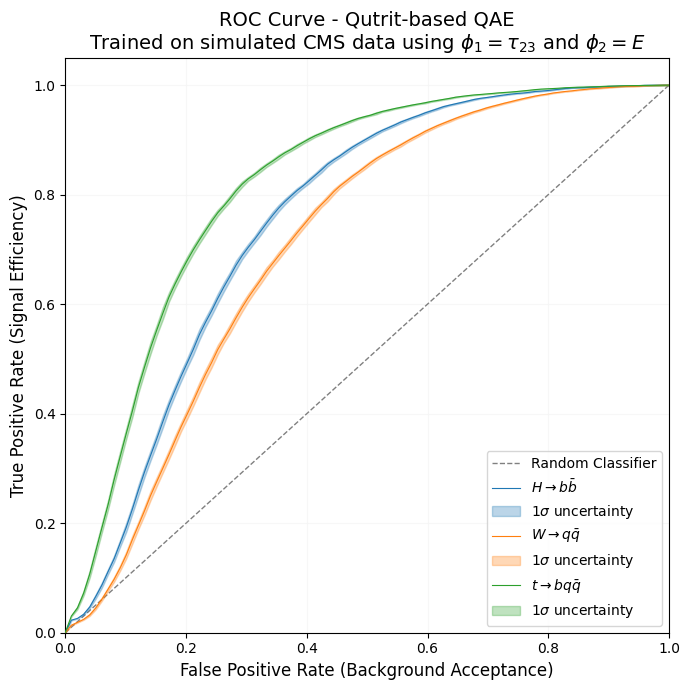

In [27]:
# ==========================================
# CONFIGURACIÓN DEL PLOT LINEAL (ROC ESTÁNDAR)
# ==========================================

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white') # Cuadrada suele verse mejor en lineal
ax.set_facecolor('white')

# Añadimos la diagonal de referencia (Modelo Aleatorio)
# Si tu curva está por debajo de esta línea, el modelo es peor que tirar una moneda
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# 1. Añadimos cada señal (usando la función anterior)
# Asegúrate de que 'common_fprs' sea lineal ahora: np.linspace(0, 1, 100)
common_fprs_linear = np.linspace(0, 1, 100)

add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t \to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# 2. AJUSTES VISUALES LINEALES
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=12)
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=12)
ax.set_title(r"ROC Curve - Qutrit-based QAE" "\n" r"Trained on simulated CMS data using $\phi_1 = \tau_{23}$ and $\phi_2 = E$", fontsize=14)

# Grid cuadrado para facilitar la lectura de la diagonal
ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

ax.legend(loc="lower right", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

### **Qutrits-based** model trained on simulated CMS data and using $\tau_{34}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau34E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [5]:
qutritsTau34E_l1_back_data = qutrits_tau34E_lt2['fil_100_back_S'].squeeze()
qutritsTau34E_l1_HToBB_data = qutrits_tau34E_lt2['fil_100_HToBB_S'].squeeze()
qutritsTau34E_l1_WToQQ_data = qutrits_tau34E_lt2['fil_100_WToQQ_S'].squeeze()
qutritsTau34E_l1_TTBar_data = qutrits_tau34E_lt2['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau34E_l1_back_data.shape)
print(qutritsTau34E_l1_HToBB_data.shape)
print(qutritsTau34E_l1_WToQQ_data.shape)
print(qutritsTau34E_l1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [8]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTau34E_l1_WToQQ_data, qutritsTau34E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_TTBar_data, qutritsTau34E_l1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_WToQQ_data, qutritsTau34E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8263 ± 0.04099285744741277
WToQQ (Boson W) vs Background |     0.3096 ± 0.03894373921652747
TTBar (Top) vs Background |     1.3509 ± 0.04090565979580305
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5299 ± 0.0012658860749742756
HToBB (Higgs) vs TTBar (Top) |     0.5266 ± 0.0012311565895549467
WToQQ (Boson W) vs TTBar (Top) |     1.0546 ± 0.0010979058953370434
-------------------------------------------------------


In [9]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau34E = []
means_WToQQ_qutritsTau34E = []
means_TTBar_qutritsTau34E = []
means_back_qutritsTau34E = []

median_HToBB_qutritsTau34E = []
median_WToQQ_qutritsTau34E = []
median_TTBar_qutritsTau34E = []
median_back_qutritsTau34E = []

auc_HToBB_list_qutritsTau34E = []
auc_TTBar_list_qutritsTau34E = []
auc_WToQQ_list_qutritsTau34E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsTau34E_l1_back_data[i]
    pdf_HToBB = qutritsTau34E_l1_HToBB_data[i]
    pdf_WToQQ = qutritsTau34E_l1_WToQQ_data[i]
    pdf_TTBar = qutritsTau34E_l1_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau34E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau34E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau34E_l1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsTau34E_l1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau34E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau34E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau34E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau34E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau34E):.4f} ± {np.std(auc_HToBB_list_qutritsTau34E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau34E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau34E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau34E):.4f} ± {np.std(auc_TTBar_list_qutritsTau34E)}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== Resultados qutritsTau34E ===
AUC HToBB: 0.7562 ± 0.009743256684395263
AUC WToQQ: 0.7153 ± 0.00922510395841654
AUC TTBar: 0.8273 ± 0.008033771551456584
=== JS distance (mean ± std) ===
HToBB  : 0.039307 ± 0.0005157348903361579
WToQQ  : 0.032624 ± 0.0006290796576747181
TTBar  : 0.041986 ± 0.0005308931095135011
----------------------------------------------------------
HToBB  : 0.041501 ± 4.274871036000373e-05
HToBB  : 0.049155 ± 3.9706418180076974e-05
WToQQ  : 0.044637 ± 3.829090205908369e-05


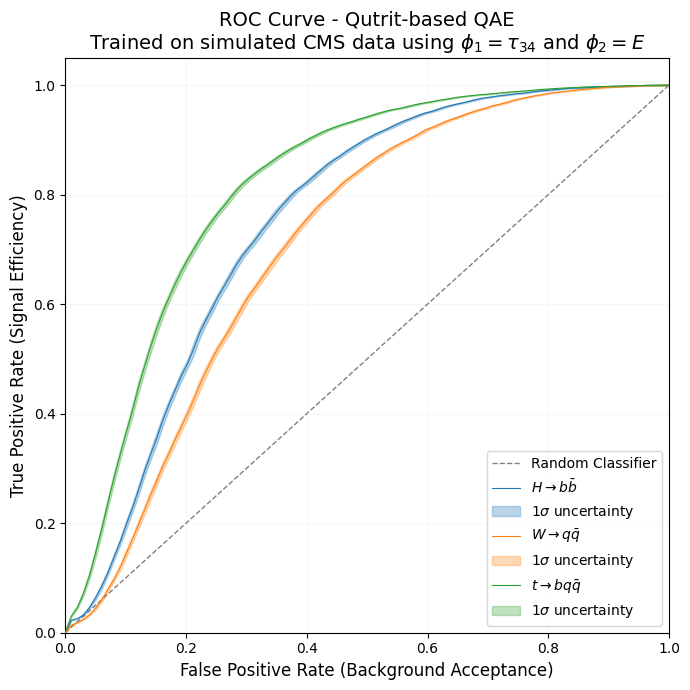

In [31]:
# ==========================================
# CONFIGURACIÓN DEL PLOT LINEAL (ROC ESTÁNDAR)
# ==========================================

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white') # Cuadrada suele verse mejor en lineal
ax.set_facecolor('white')

# Añadimos la diagonal de referencia (Modelo Aleatorio)
# Si tu curva está por debajo de esta línea, el modelo es peor que tirar una moneda
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# 1. Añadimos cada señal (usando la función anterior)
# Asegúrate de que 'common_fprs' sea lineal ahora: np.linspace(0, 1, 100)
common_fprs_linear = np.linspace(0, 1, 100)

add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t \to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# 2. AJUSTES VISUALES LINEALES
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=12)
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=12)
ax.set_title(r"ROC Curve - Qutrit-based QAE" "\n" r"Trained on simulated CMS data using $\phi_1 = \tau_{34}$ and $\phi_2 = E$", fontsize=14)

# Grid cuadrado para facilitar la lectura de la diagonal
ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

ax.legend(loc="lower right", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

### **Qutrits-based** model trained on simulated CMS data and using $\tau_{1}$, $\tau_{2}$, $\tau_{3}$ and $\tau_{4}$ (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTaus`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [23]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTaus = []
means_WToQQ_qutritsTaus = []
means_TTBar_qutritsTaus = []
means_back_qutritsTaus = []

median_HToBB_qutritsTaus = []
median_WToQQ_qutritsTaus = []
median_TTBar_qutritsTaus = []
median_back_qutritsTaus = []

auc_HToBB_list_qutritsTaus = []
auc_TTBar_list_qutritsTaus = []
auc_WToQQ_list_qutritsTaus = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

# =========================
# Datos (Adaptados a qutritsTaus)
# =========================

qutritsTaus_back  = qutritsTaus['fil_100_back_S'].squeeze()
qutritsTaus_HToBB = qutritsTaus['fil_100_HToBB_S'].squeeze()
qutritsTaus_WToQQ = qutritsTaus['fil_100_WToQQ_S'].squeeze()
qutritsTaus_TTBar = qutritsTaus['fil_100_TTBar_S'].squeeze()

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- Stats ----------
    means_back_qutritsTaus.append(np.mean(qutritsTaus_back[i]))
    means_HToBB_qutritsTaus.append(np.mean(qutritsTaus_HToBB[i]))
    means_WToQQ_qutritsTaus.append(np.mean(qutritsTaus_WToQQ[i]))
    means_TTBar_qutritsTaus.append(np.mean(qutritsTaus_TTBar[i]))

    median_back_qutritsTaus.append(np.median(qutritsTaus_back[i]))
    median_HToBB_qutritsTaus.append(np.median(qutritsTaus_HToBB[i]))
    median_WToQQ_qutritsTaus.append(np.median(qutritsTaus_WToQQ[i]))
    median_TTBar_qutritsTaus.append(np.median(qutritsTaus_TTBar[i]))

    # ---------- PDFs ----------
    pdf_back  = qutritsTaus_back[i]
    pdf_HToBB = qutritsTaus_HToBB[i]
    pdf_WToQQ = qutritsTaus_WToQQ[i]
    pdf_TTBar = qutritsTaus_TTBar[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTaus_back[i].ravel()
    anomaly_scores_HToBB = 1 - qutritsTaus_HToBB[i].ravel()
    anomaly_scores_TTBar = 1 - qutritsTaus_TTBar[i].ravel()
    anomaly_scores_WToQQ = 1 - qutritsTaus_WToQQ[i].ravel()

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTaus.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTaus.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTaus.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTaus ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTaus):.4f} ± {np.std(auc_HToBB_list_qutritsTaus)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTaus):.4f} ± {np.std(auc_WToQQ_list_qutritsTaus)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTaus):.4f} ± {np.std(auc_TTBar_list_qutritsTaus)}")

print("\n=== JS Distance (Promedio) ===")
print(f"JSD HToBB-Back: {np.mean(jsd_HToBB_back):.4f} ± {np.std(jsd_HToBB_back)}")
print(f"JSD WToQQ-Back: {np.mean(jsd_WToQQ_back):.4f} ± {np.std(jsd_WToQQ_back)}")
print(f"JSD TTBar-Back: {np.mean(jsd_TTBar_back):.4f} ± {np.std(jsd_TTBar_back)}")

=== Resultados qutritsTaus ===
AUC HToBB: 0.6871 ± 0.0018208562755617846
AUC WToQQ: 0.6334 ± 0.0010184908294326716
AUC TTBar: 0.8669 ± 0.0009995703486640828

=== JS Distance (Promedio) ===
JSD HToBB-Back: 0.0042 ± 1.7519867175307178e-05
JSD WToQQ-Back: 0.0043 ± 1.696803432439284e-05
JSD TTBar-Back: 0.0059 ± 1.6490104232286227e-05


In [ ]:
qutritsTaus_back = qutritsTaus['fil_100_back_S']
qutritsTaus_HToBB = qutritsTaus['fil_100_HToBB_S']
qutritsTaus_WToQQ = qutritsTaus['fil_100_WToQQ_S']
qutritsTaus_TTBar = qutritsTaus['fil_100_TTBar_S']  

qutritsTaus_back = qutritsTaus_back.squeeze()
qutritsTaus_HToBB = qutritsTaus_HToBB.squeeze()
qutritsTaus_WToQQ = qutritsTaus_WToQQ.squeeze()
qutritsTaus_TTBar = qutritsTaus_TTBar.squeeze()

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTaus_HToBB, qutritsTaus_back)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTaus_WToQQ, qutritsTaus_back)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTaus_TTBar, qutritsTaus_back)
print("=== Wasserstein Distance (mean ± std) ===")
print(f"HToBB  : {W_HToBB_mean:.4f} ± {W_HToBB_std}")
print(f"WToQQ  : {W_WToQQ_mean:.4f} ± {W_WToQQ_std}")
print(f"TTBar  : {W_TTBar_mean:.4f} ± {W_TTBar_std}")

=== Wasserstein Distance (mean ± std) ===
HToBB  : 0.2591 ± 0.005993441968763302
WToQQ  : 0.1862 ± 0.0030275880323208273
TTBar  : 1.1484 ± 0.01717613512169138


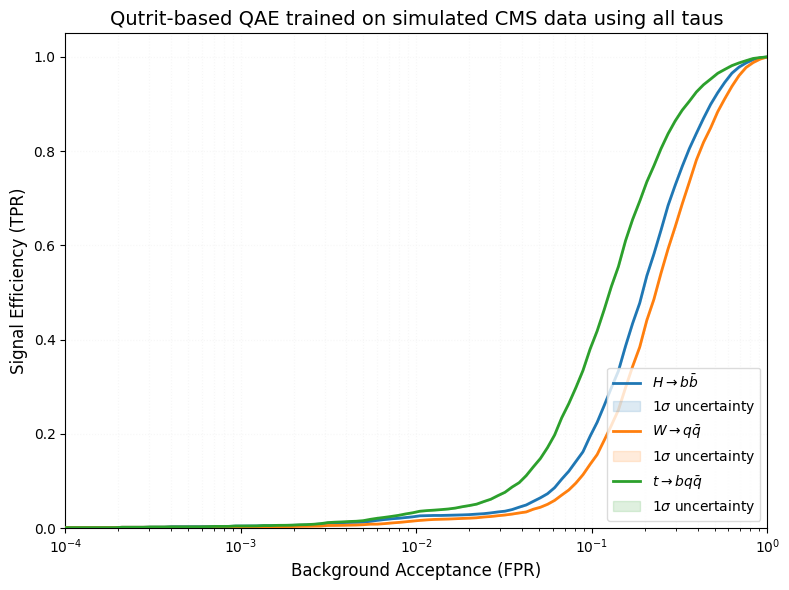

In [23]:
common_fprs = np.logspace(-4, 0, 100)

# 2. Creamos la figura con FONDO BLANCO
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

# 3. Añadimos cada señal con un color diferente
# Nota: Aquí pasas tus listas de FPR/TPR que ya tienes calculadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs)

# 4. Ajustes visuales para que quede impecable (Sin líneas verticales en los bordes)
ax.set_xscale("log")
ax.set_xlim(common_fprs.min(), 1.0) # Corta justo donde empiezan los datos
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("Background Acceptance (FPR)", fontsize=12)
ax.set_ylabel("Signal Efficiency (TPR)", fontsize=12)
ax.set_title(r"Qutrit-based QAE trained on simulated CMS data using all taus", fontsize=14)

# Grid muy sutil (casi invisible) para mantener el fondo blanco
ax.grid(True, which="both", ls=":", color='whitesmoke', alpha=0.8)

# Leyenda con fondo blanco
ax.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

### **Some prints to saw the result of previus calculations**

In [ ]:

print("----- Mean AUC Results -----")
print("--------------------------------")
print("----------QUBITS REAL-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qubitsReal)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qubitsReal)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qubitsReal)
print("----------QUTRITS REAL-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsReal)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsReal)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsReal)
print("--------------------------------")
print("--------SIMULATED DATA----------")
print("----------QUBITS-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qubits)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qubits)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qubits)
print("----------QUTRITS D0DZ-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsd0dz)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsd0dz)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsd0dz)
print("----------QUTRITS TAU12E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau12E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau12E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau12E)
print("----------QUTRITS TAU23E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau23E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau23E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau23E)
print("----------QUTRITS TAU34E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau34E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau34E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau34E)
print("----------QUTRITS ALL TAUS-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTaus)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTaus)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTaus)

----- Mean AUC Results -----
--------------------------------
----------QUBITS REAL-------------
Mean AUC HToBB:  0.6687823041555001
Mean AUC  TTBar:  0.7661036927505002
Mean AUC  WToQQ:  0.6219458159259998
----------QUTRITS REAL-------------
Mean AUC HToBB:  0.7136422438519996
Mean AUC  TTBar:  0.7927688938940003
Mean AUC  WToQQ:  0.671160632956
--------------------------------
--------SIMULATED DATA----------
----------QUBITS-------------
Mean AUC HToBB:  0.775168388676603
Mean AUC  TTBar:  0.845749885190557
Mean AUC  WToQQ:  0.7333995047039111
----------QUTRITS D0DZ-------------
Mean AUC HToBB:  0.7312929073160003
Mean AUC  TTBar:  0.8099593322309999
Mean AUC  WToQQ:  0.6880127092720001
----------QUTRITS TAU12E-------------
Mean AUC HToBB:  0.7626888172579999
Mean AUC  TTBar:  0.8329333438459997
Mean AUC  WToQQ:  0.7216948242079998
----------QUTRITS TAU23E-------------
Mean AUC HToBB:  0.7634379140569999
Mean AUC  TTBar:  0.8335271029619997
Mean AUC  WToQQ:  0.7231186645800001
-----

In [ ]:
print("--------------------------------")
print("-----Fidelity Metrics-----")
print("----------------------------")
print("-----Qubits Real Fidelity-----") 
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qubitsReal))
print("Median Fidelity: ", np.median(median_HToBB_qubitsReal))
print("Desviación estándar: ", np.std(means_HToBB_qubitsReal))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qubitsReal))
print("Median Fidelity: ", np.median(median_TTBar_qubitsReal))
print("Desviación estándar: ", np.std(means_TTBar_qubitsReal))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qubitsReal))
print("Median Fidelity: ", np.median(median_WToQQ_qubitsReal))
print("Desviación estándar: ", np.std(means_WToQQ_qubitsReal))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qubitsReal) - np.mean(means_TTBar_qubitsReal))
print("WToQQ - HToBB: ",  np.mean(means_WToQQ_qubitsReal)- np.mean(means_HToBB_qubitsReal))
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qubitsReal) - np.mean(means_TTBar_qubitsReal))
print("----Diferencias de medianas-------")
print("HToBB - TTBar: ", np.median(median_HToBB_qubitsReal) - np.median(median_TTBar_qubitsReal))
print("WToQQ - HToBB: ",  np.median(median_WToQQ_qubitsReal)- np.median(median_HToBB_qubitsReal))
print("WToQQ - TTBar: ", np.median(median_WToQQ_qubitsReal) - np.median(median_TTBar_qubitsReal))

print("----------------------------")
print("-----Qutrits Real Fidelity-----") 
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsReal))
print("Median Fidelity: ", np.median(median_HToBB_qutritsReal))
print("Desviación estándar: ", np.std(means_HToBB_qutritsReal))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsReal))
print("Median Fidelity: ", np.median(median_TTBar_qutritsReal))
print("Desviación estándar: ", np.std(means_TTBar_qutritsReal))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsReal))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsReal))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsReal))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsReal) - np.mean(means_TTBar_qutritsReal))
print("WToQQ - HToBB : ",  np.mean(means_WToQQ_qutritsReal) - np.mean(means_HToBB_qutritsReal))
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qutritsReal) - np.mean(means_TTBar_qutritsReal) )   
print("----Diferencias de medianas-------")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsReal) - np.median(median_TTBar_qutritsReal))
print("WToQQ - HToBB : ",  np.median(median_WToQQ_qutritsReal) - np.median(median_HToBB_qutritsReal))
print("WToQQ - TTBar: ", np.median(median_WToQQ_qutritsReal) - np.median(median_TTBar_qutritsReal) ) 
print("----------------------------")
print("-----Simulated Data Fidelities-----")
print("-----Qubits Fidelity-----") 
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qubits))
print("Median Fidelity: ", np.median(median_HToBB_qubits))
print("Desviación estándar: ", np.std(means_HToBB_qubits))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qubits))
print("Median Fidelity: ", np.median(median_TTBar_qubits))
print("Desviación estándar: ", np.std(means_TTBar_qubits))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qubits))
print("Median Fidelity: ", np.median(median_WToQQ_qubits))
print("Desviación estándar: ", np.std(means_WToQQ_qubits))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qubits) - np.mean(means_TTBar_qubits))
print("WToQQ - HToBB: ", np.mean(means_WToQQ_qubits) - np.mean(means_HToBB_qubits) )
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qubits) - np.mean(means_TTBar_qubits) )
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qubits) - np.median(median_TTBar_qubits))
print("WToQQ - HToBB: ", np.median(median_WToQQ_qubits) - np.median(median_HToBB_qubits) )
print("WToQQ - TTBar: ", np.median(median_WToQQ_qubits) - np.median(median_TTBar_qubits) )
print("----------------------------")       
print("-----Qutrits D0DZ Fidelity-----")
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsd0dz))
print("Median Fidelity: ", np.median(median_HToBB_qutritsd0dz))
print("Desviación estándar: ", np.std(means_HToBB_qutritsd0dz))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsd0dz))
print("Median Fidelity: ", np.median(median_TTBar_qutritsd0dz))
print("Desviación estándar: ", np.std(means_TTBar_qutritsd0dz))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsd0dz))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsd0dz))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsd0dz))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsd0dz) - np.mean(means_TTBar_qutritsd0dz))   
print("WToQQ - HToBB : ", np.mean(means_WToQQ_qutritsd0dz) - np.mean(means_HToBB_qutritsd0dz))
print("WToQQ - TTBar : ", np.mean(means_WToQQ_qutritsd0dz) - np.mean(means_TTBar_qutritsd0dz) )
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsd0dz) - np.median(median_TTBar_qutritsd0dz))   
print("WToQQ - HToBB : ", np.median(median_WToQQ_qutritsd0dz) - np.median(median_HToBB_qutritsd0dz))
print("WToQQ - TTBar : ", np.median(median_WToQQ_qutritsd0dz) - np.median(median_TTBar_qutritsd0dz) )
print("----------------------------")       
print("-----Qutrits Tau12E Fidelity-----")
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsTau12E))
print("Median Fidelity: ", np.median(median_HToBB_qutritsTau12E))
print("Desviación estándar: ", np.std(means_HToBB_qutritsTau12E))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsTau12E))
print("Median Fidelity: ", np.median(median_TTBar_qutritsTau12E))
print("Desviación estándar: ", np.std(means_TTBar_qutritsTau12E))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsTau12E))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsTau12E))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsTau12E))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsTau12E) - np.mean(means_TTBar_qutritsTau12E))   
print("HToBB - WToQQ : ",  np.mean(means_HToBB_qutritsTau12E) - np.mean(means_WToQQ_qutritsTau12E))
print("TTBar -  WToQQ: ",  np.mean(means_TTBar_qutritsTau12E) - np.mean(means_WToQQ_qutritsTau12E))
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsTau12E) - np.median(median_TTBar_qutritsTau12E))   
print("HToBB - WToQQ : ",  np.median(median_HToBB_qutritsTau12E) - np.median(median_WToQQ_qutritsTau12E))
print("TTBar -  WToQQ: ",  np.median(median_TTBar_qutritsTau12E) - np.median(median_WToQQ_qutritsTau12E))
print("----------------------------")       
print("-----Qutrits Tau23E Fidelity-----")
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsTau23E))
print("Median Fidelity: ", np.median(median_HToBB_qutritsTau23E))
print("Desviación estándar: ", np.std(means_HToBB_qutritsTau23E))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsTau23E))
print("Median Fidelity: ", np.median(median_TTBar_qutritsTau23E))
print("Desviación estándar: ", np.std(means_TTBar_qutritsTau23E))
print("------WToQQ------")  
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsTau23E))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsTau23E))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsTau23E))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsTau23E) - np.mean(means_TTBar_qutritsTau23E))   
print("WToQQ - HToBB: ", np.mean(means_WToQQ_qutritsTau23E) - np.mean(means_HToBB_qutritsTau23E))
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qutritsTau23E) - np.mean(means_TTBar_qutritsTau23E))
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsTau23E) - np.median(median_TTBar_qutritsTau23E))   
print("WToQQ - HToBB: ", np.median(median_WToQQ_qutritsTau23E) - np.median(median_HToBB_qutritsTau23E))
print("WToQQ - TTBar: ", np.median(median_WToQQ_qutritsTau23E) - np.median(median_TTBar_qutritsTau23E))
print("----------------------------")
print("-----Qutrits Tau34E Fidelity-----")
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsTau34E))
print("Median Fidelity: ", np.median(median_HToBB_qutritsTau34E))
print("Desviación estándar: ", np.std(means_HToBB_qutritsTau34E))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsTau34E))
print("Median Fidelity: ", np.median(median_TTBar_qutritsTau34E))
print("Desviación estándar: ", np.std(means_TTBar_qutritsTau34E))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsTau34E))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsTau34E))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsTau34E))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsTau34E) - np.mean(means_TTBar_qutritsTau34E))   
print("WToQQ - HToBB: ",  np.mean(means_WToQQ_qutritsTau34E) - np.mean(means_HToBB_qutritsTau34E))
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qutritsTau34E) - np.mean(means_TTBar_qutritsTau34E))
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsTau34E) - np.median(median_TTBar_qutritsTau34E))   
print("WToQQ - HToBB: ",  np.median(median_WToQQ_qutritsTau34E) - np.median(median_HToBB_qutritsTau34E))
print("WToQQ - TTBar: ", np.median(median_WToQQ_qutritsTau34E) - np.median(median_TTBar_qutritsTau34E))
print("----------------------------")       
print("-----Qutrits All Taus Fidelity-----")
print("------HToBB------")
print("Mean Fidelity: ", np.mean(means_HToBB_qutritsTaus))
print("Median Fidelity: ", np.median(median_HToBB_qutritsTaus))
print("Desviación estándar: ", np.std(means_HToBB_qutritsTaus))
print("------TTBar------")
print("Mean Fidelity: ", np.mean(means_TTBar_qutritsTaus))
print("Median Fidelity: ", np.median(median_TTBar_qutritsTaus))
print("Desviación estándar: ", np.std(means_TTBar_qutritsTaus))
print("------WToQQ------")
print("Mean Fidelity: ", np.mean(means_WToQQ_qutritsTaus))
print("Median Fidelity: ", np.median(median_WToQQ_qutritsTaus))
print("Desviación estándar: ", np.std(means_WToQQ_qutritsTaus))
print("Difereferenicas entre medias")
print("HToBB - TTBar: ", np.mean(means_HToBB_qutritsTaus) - np.mean(means_TTBar_qutritsTaus))   
print("WToQQ - HToBB: ", np.mean(means_WToQQ_qutritsTaus) - np.mean(means_HToBB_qutritsTaus))
print("WToQQ - TTBar: ", np.mean(means_WToQQ_qutritsTaus) - np.mean(means_TTBar_qutritsTaus))   
print("Difereferenicas entre medianas")
print("HToBB - TTBar: ", np.median(median_HToBB_qutritsTaus) - np.median(median_TTBar_qutritsTaus))   
print("WToQQ - HToBB: ", np.median(median_WToQQ_qutritsTaus) - np.median(median_HToBB_qutritsTaus))
print("WToQQ - TTBar: ", np.median(median_WToQQ_qutritsTaus) - np.median(median_TTBar_qutritsTaus))   



--------------------------------
-----Fidelity Metrics-----
----------------------------
-----Qubits Real Fidelity-----
------HToBB------
Mean Fidelity:  99.69336882398876
Median Fidelity:  99.98854507030867
Desviación estándar:  0.004843894533293836
------TTBar------
Mean Fidelity:  99.64076087505481
Median Fidelity:  99.98079529304192
Desviación estándar:  0.004802562207507373
------WToQQ------
Mean Fidelity:  99.71616924459862
Median Fidelity:  99.9907655135124
Desviación estándar:  0.004805043461643602
Difereferenicas entre medias
HToBB - TTBar:  0.05260794893395371
WToQQ - HToBB:  0.022800420609854655
WToQQ - TTBar:  0.07540836954380836
----Diferencias de medianas-------
HToBB - TTBar:  0.007749777266752744
WToQQ - HToBB:  0.0022204432037256083
WToQQ - TTBar:  0.009970220470478353
----------------------------
-----Qutrits Real Fidelity-----
------HToBB------
Mean Fidelity:  98.43406242705758
Median Fidelity:  99.8612585132402
Desviación estándar:  0.0013862734263823222
------TTBar

---
---


❗❗This code organizes the computed Jensen-Shannon divergences (JSD) between different pairs 
(HToBB, WToQQ, TTBar) for multiple datasets (Qubits, Qutrits, and their variations). 
It then iterates through each dataset and prints the mean JSD values for each pair.❗❗


⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇⬇

---
---

In [ ]:
datasets = {
    "Qubits Real": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qubitsReal,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qubitsReal,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qubitsReal
    },
    "Qutrits Real": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsReal,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsReal,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsReal
    },
    "Qubits": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qubits,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qubits,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qubits
    },
    "Qutrits d0dz": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsd0dz,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsd0dz,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsd0dz
    },
    "Qutrits Tau12E": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsTau12E,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsTau12E,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsTau12E
    },
    "Qutrits Tau23E": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsTau23E,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsTau23E,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsTau23E
    },
    "Qutrits Tau34E": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsTau34E,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsTau34E,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsTau34E
    },
    "Qutrits Taus": {
        "HToBB_WToQQ": mean_jsd_HToBB_WToQQ_qutritsTaus,
        "HToBB_TTBar": mean_jsd_HToBB_TTBar_qutritsTaus,
        "WToQQ_TTBar": mean_jsd_WToQQ_TTBar_qutritsTaus
    }
}

for name, metrics in datasets.items():
    print(f"--- {name} ---")
    for pair, value in metrics.items():
        print(f"{pair}: {value:.4f}")
    print()


--- Qubits Real ---
HToBB_WToQQ: 0.0143
HToBB_TTBar: 0.0128
WToQQ_TTBar: 0.0139

--- Qutrits Real ---
HToBB_WToQQ: 0.0445
HToBB_TTBar: 0.0533
WToQQ_TTBar: 0.0487

--- Qubits ---
HToBB_WToQQ: 0.0143
HToBB_TTBar: 0.0128
WToQQ_TTBar: 0.0139

--- Qutrits d0dz ---
HToBB_WToQQ: 0.0445
HToBB_TTBar: 0.0533
WToQQ_TTBar: 0.0487

--- Qutrits Tau12E ---
HToBB_WToQQ: 0.0445
HToBB_TTBar: 0.0533
WToQQ_TTBar: 0.0487

--- Qutrits Tau23E ---
HToBB_WToQQ: 0.0445
HToBB_TTBar: 0.0533
WToQQ_TTBar: 0.0487

--- Qutrits Tau34E ---
HToBB_WToQQ: 0.0445
HToBB_TTBar: 0.0533
WToQQ_TTBar: 0.0487

--- Qutrits Taus ---
HToBB_WToQQ: 0.0037
HToBB_TTBar: 0.0054
WToQQ_TTBar: 0.0055



# **SOME PLOTS** (ROC Curves, Fidelitiy distributions...)

AUC (QCD vs H→bb): 0.7761
AUC (QCD vs t→bqq): 0.8570
AUC (QCD vs W→qq): 0.7308


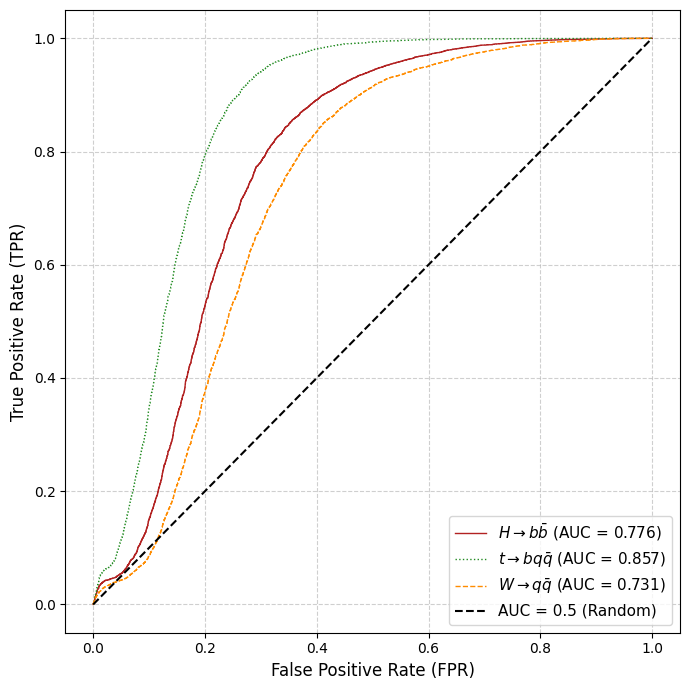

-------------------------------------------
KL Divergence (Qubits Real Fidelity)
-------------------------------------
HToBB || TTBar:  nan
TTBar || HToBB:  nan
WToQQ || HToBB: 0.022620665506836078
HToBB || WToQQ: 0.0221304162737243
WToQQ || TTBar: nan
TTBar || WToQQ: nan


/Users/mcarou/Documents/PhD/Proyecto/Research-Intership-Memory/python_env/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

qubits10 = np.load('./Qubits10.npz', allow_pickle=True)
qubits10_back = qubits10['fil_100_back_S']
qubits10_HToBB = qubits10['fil_100_HToBB_S']
qubits10_WToQQ = qubits10['fil_100_WToQQ_S']
qubits10_TTBar = qubits10['fil_100_TTBar_S']
qubits10_back = qubits10_back.squeeze()
qubits10_HToBB = qubits10_HToBB.squeeze()
qubits10_WToQQ = qubits10_WToQQ.squeeze()
qubits10_TTBar = qubits10_TTBar.squeeze()
# --- Anomaly scores (1 - Fidelity) ---
anomaly_scores_back = 1 - np.array(qubits10_back)
anomaly_scores_HToBB = 1 - np.array(qubits10_HToBB)
anomaly_scores_TTBar = 1 - np.array(qubits10_TTBar)
anomaly_scores_WToQQ = 1 - np.array(qubits10_WToQQ)

# --- Calcular AUC ---
auc_HToBB = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
)

auc_TTBar = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
)

auc_WToQQ = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
)

print(f"AUC (QCD vs H→bb): {auc_HToBB:.4f}")
print(f"AUC (QCD vs t→bqq): {auc_TTBar:.4f}")
print(f"AUC (QCD vs W→qq): {auc_WToQQ:.4f}")

# --- Graficar curvas ROC ---
plt.figure(figsize=(7, 7))

# H→bb
fpr_HToBB, tpr_HToBB, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
)
plt.plot(fpr_HToBB, tpr_HToBB, color='firebrick', linewidth=1,
         label=rf'$H \rightarrow b\bar{{b}}$ (AUC = {auc_HToBB:.3f})')

# t→bqq
fpr_TTBar, tpr_TTBar, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
)
plt.plot(fpr_TTBar, tpr_TTBar, color='forestgreen', linewidth=1, linestyle=':',
         label=rf'$t \rightarrow bq\bar{{q}}$ (AUC = {auc_TTBar:.3f})')

# W→qq
fpr_WToQQ, tpr_WToQQ, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
)
plt.plot(fpr_WToQQ, tpr_WToQQ, color='darkorange', linewidth=1, linestyle='--',
         label=rf'$W \rightarrow q\bar{{q}}$ (AUC = {auc_WToQQ:.3f})')

# Línea aleatoria (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label=r'AUC = 0.5 (Random)')

# --- Personalización ejes y leyenda ---
plt.xlabel(r'False Positive Rate (FPR)', fontsize=12)
plt.ylabel(r'True Positive Rate (TPR)', fontsize=12)
#plt.title(r'ROC Curve ', fontsize=12, pad=5)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajuste márgenes y guardado
plt.tight_layout()
plt.savefig("metricas_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

import numpy as np
from scipy.stats import entropy   # implementa KL divergence

def kl_divergence(p_samples, q_samples, bins=50):

    p_hist, bin_edges = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bin_edges, density=True)

    # evitar ceros (KL no está definida)
    p_hist += 1e-10
    q_hist += 1e-10

    return entropy(p_hist, q_hist)   # KL(p||q)

print("-------------------------------------------")
print("KL Divergence (Qubits Real Fidelity)")
print("-------------------------------------")

print("HToBB || TTBar: ", kl_divergence(qubits10_HToBB, anomaly_scores_TTBar))
print("TTBar || HToBB: ", kl_divergence(anomaly_scores_TTBar, qubits10_HToBB))

print("WToQQ || HToBB:", kl_divergence(qubits10_WToQQ, qubits10_HToBB))
print("HToBB || WToQQ:", kl_divergence(qubits10_HToBB, qubits10_WToQQ))

print("WToQQ || TTBar:", kl_divergence(qubits10_WToQQ, anomaly_scores_TTBar))
print("TTBar || WToQQ:", kl_divergence(anomaly_scores_TTBar, qubits10_WToQQ))

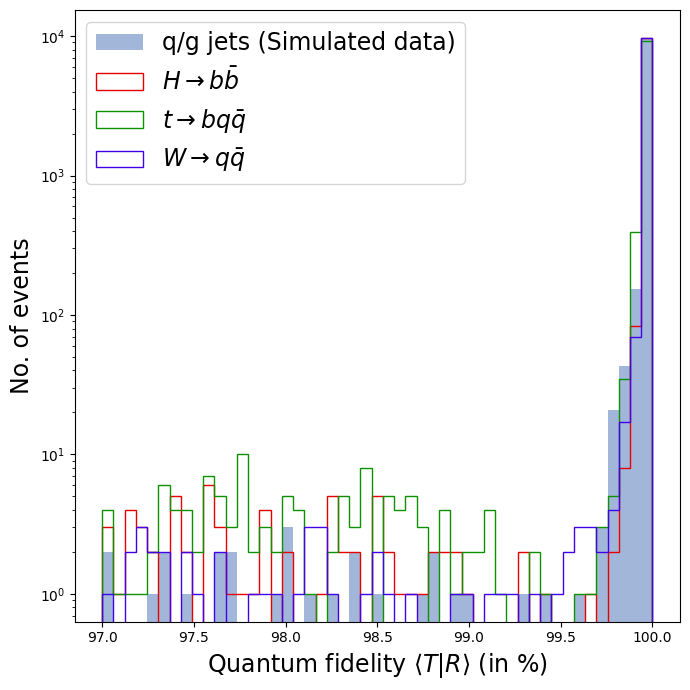

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qubits_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qubits_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qubits_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qubits_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

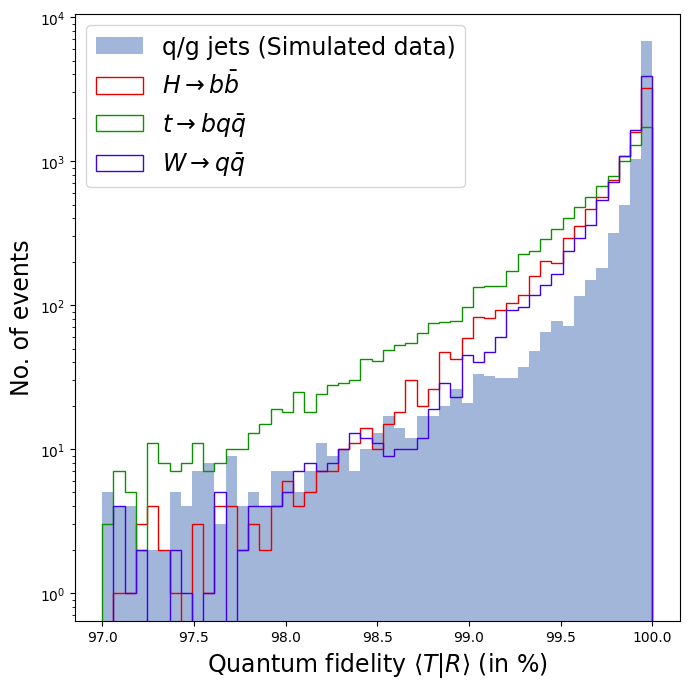

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsd0dz_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsd0dz_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsd0dz_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsd0dz_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

qutritsTau12E_back = qutritsTau12E_back.squeeze()
qutritsTau12E_HToBB = qutritsTau12E_HToBB.squeeze()
qutritsTau12E_WToQQ = qutritsTau12E_WToQQ.squeeze()
qutritsTau12E_TTBar = qutritsTau12E_TTBar.squeeze()

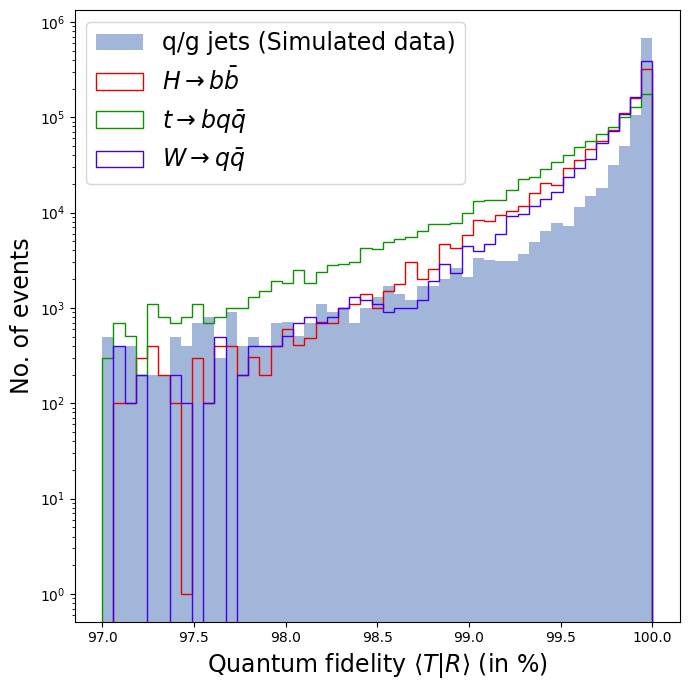

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsd0dz_back.flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsd0dz_HToBB.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsd0dz_TTBar.flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsd0dz_WToQQ.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

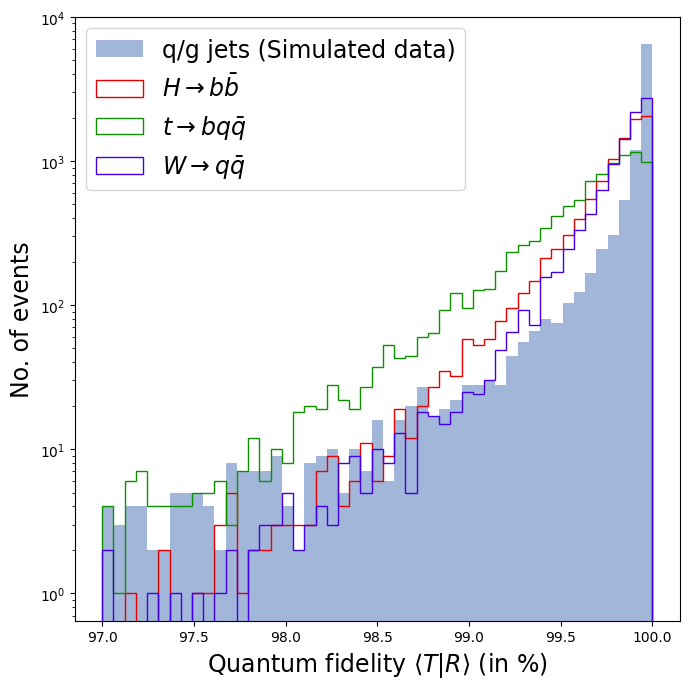

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsTau12E_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsTau12E_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsTau12E_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsTau12E_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

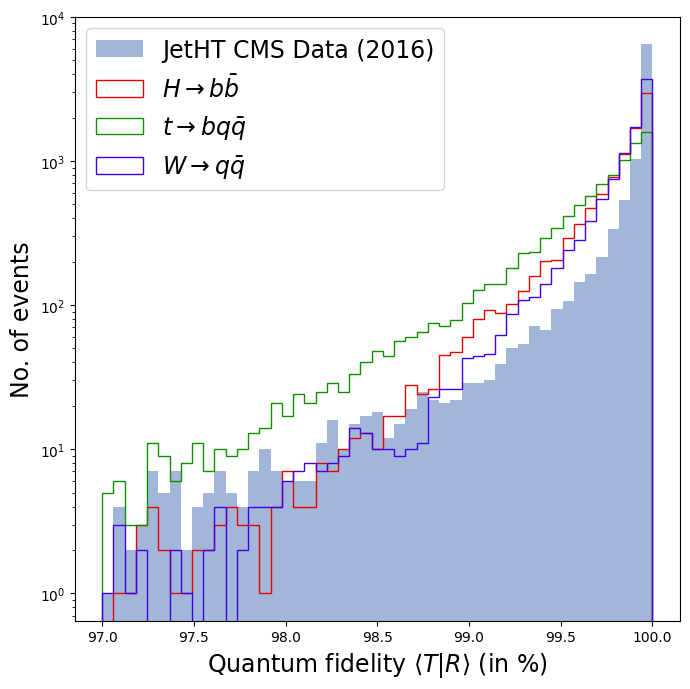

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsReal_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'JetHT CMS Data (2016)')

#  H → bb : 
plt.hist(qutritsReal_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsReal_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsReal_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

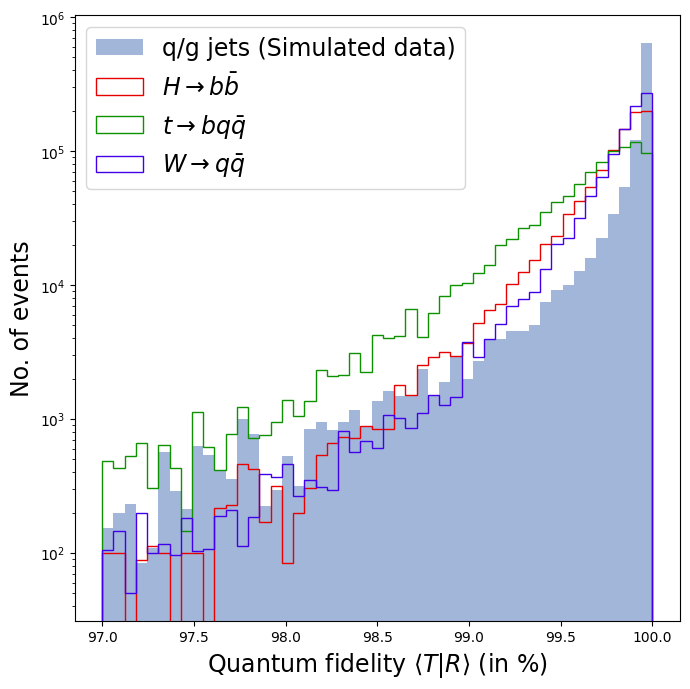

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsTau34E_back.flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsTau34E_HToBB.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsTau34E_TTBar.flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsTau34E_WToQQ.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

## **Dispersion Analysis**

From this point onward, we will analyze how dispersed the results are among the different datasets results. 
This helps to understand the variability and consistency of the computed metrics.


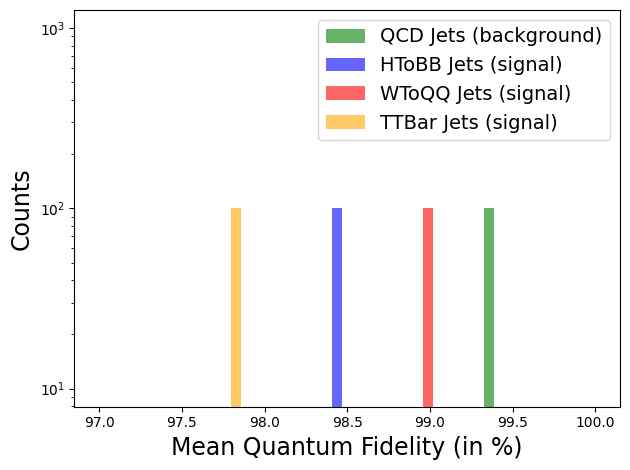

In [ ]:
bins = np.linspace(97, 100, 50)
plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

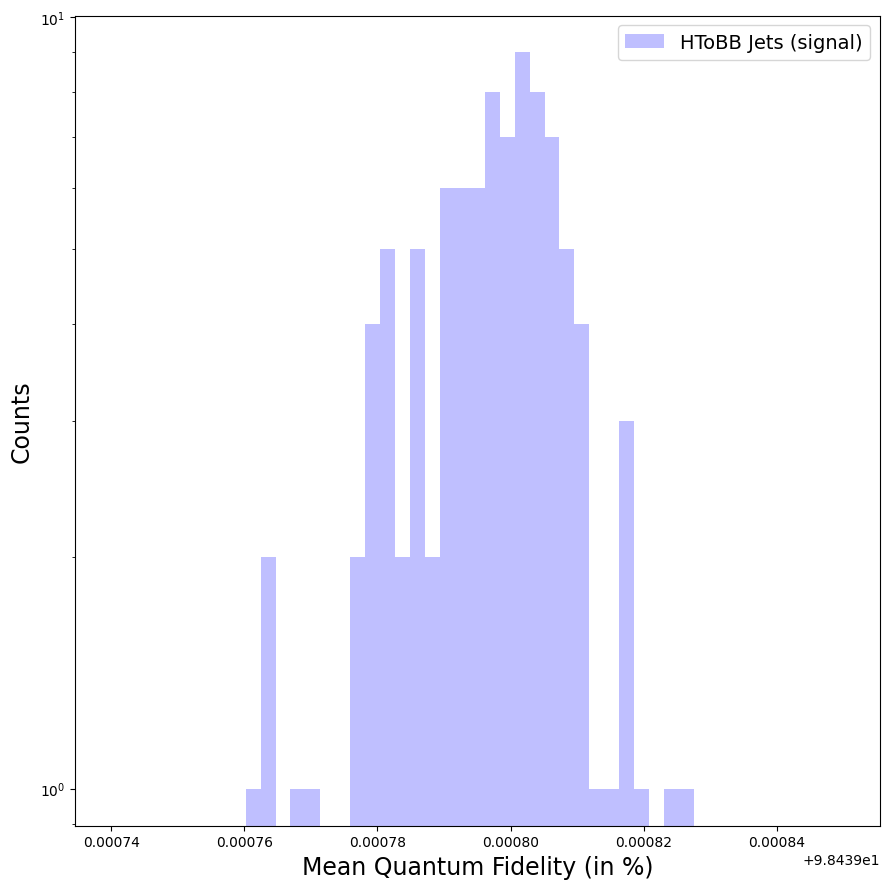

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(98.43974, 98.43985, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.25, color='b', label='HToBB Jets (signal)', log=True)
#plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
#plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

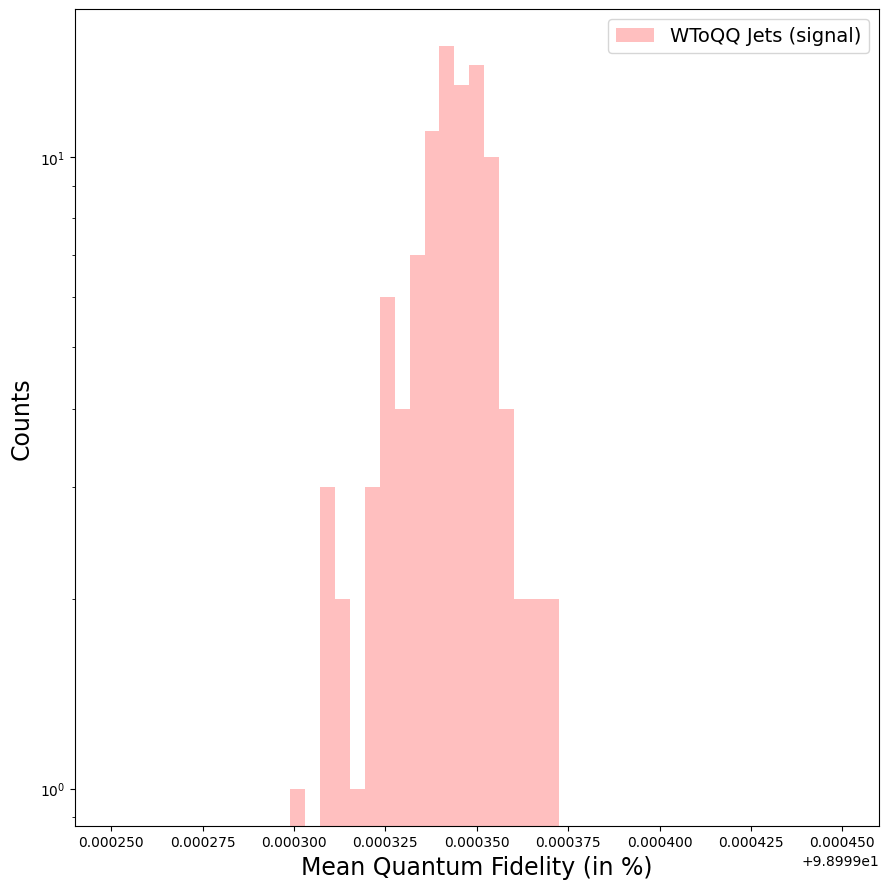

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(98.99925, 98.99945, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
#plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.25, color='r', label='WToQQ Jets (signal)', log=True)
#plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

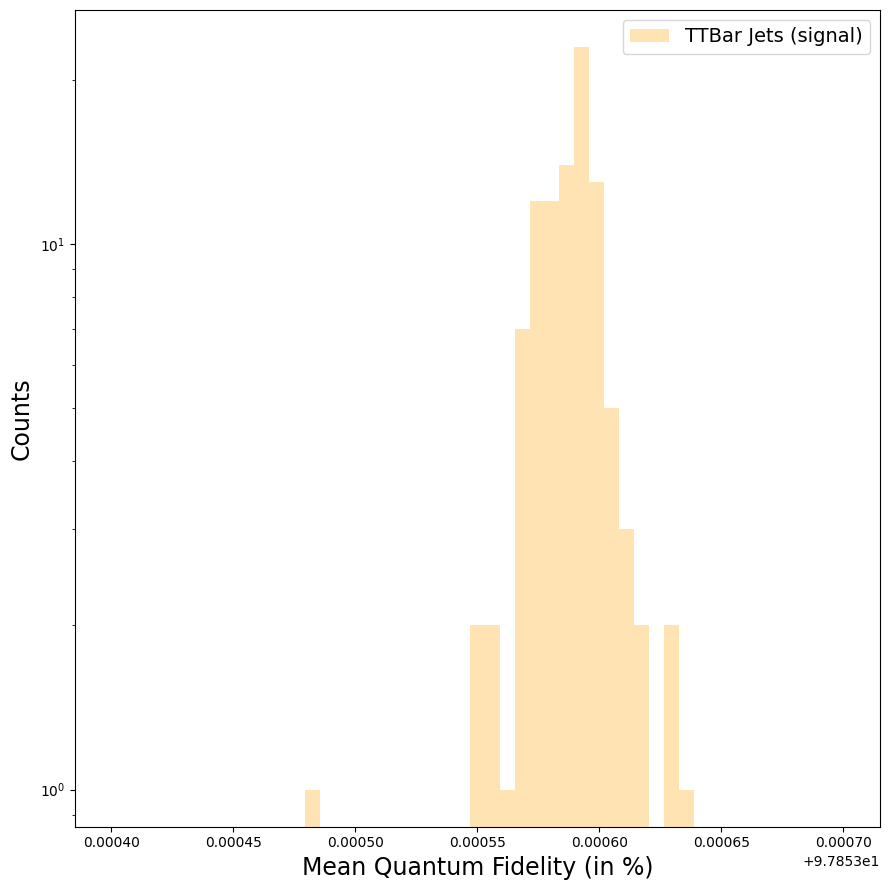

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(97.8534, 97.8537, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
#plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
#plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.3, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()